In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # Set a consistent theme for all plots
plt.rcParams['figure.dpi'] = 100 # Set a higher resolution for plots


In [4]:
df = pd.read_csv('../data/hotel_bookings_clean.csv')

df.shape

(113380, 34)

In [ ]:
# Remove data entry errors — Undefined segment has 100% cancellation rate and ADR of 15€
df = df[df['market_segment'] != 'Undefined']

In [5]:
segment = df.groupby('market_segment')['adr'].mean().round(2).sort_values(ascending=False)
print(segment)

market_segment
Online TA        111.19
Direct           106.91
Aviation         102.74
Offline TA/TO     87.66
Groups            79.61
Corporate         70.17
Complementary     34.04
Undefined         15.00
Name: adr, dtype: float64


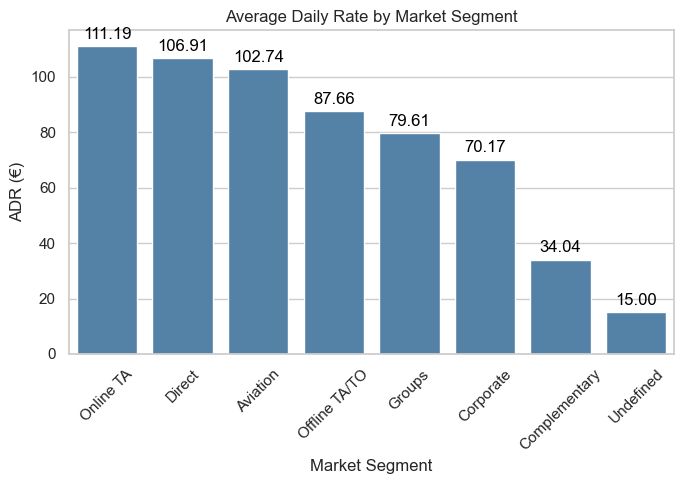

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=segment.index,
            y=segment.values,
            color='steelblue',
            ax=ax)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, color='black')
plt.title('Average Daily Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('ADR (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/adr_by_market_segment.png', bbox_inches='tight')
plt.show()

In [ ]:
decoup = pd.cut(df['lead_time'], bins=[0, 7, 30, 90, 180, np.inf], labels=['0-7', '8-30', '31-90', '91-180', '180+'])

df['lead_time_group'] = decoup

lead_time_adr = df.groupby('lead_time_group', observed=True)['adr'].mean().round(2)
print(lead_time_adr)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=lead_time_adr.index, 
            y=lead_time_adr.values,
            color='steelblue',
            ax=ax)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, color='black')
plt.title('Average Daily Rate by Lead Time Group')
plt.xlabel('Lead Time Group (days)')
plt.ylabel('ADR (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../exports/adr_by_lead_time_group.png', bbox_inches='tight')
plt.show()

In [9]:
#average cancellation rate by market segment
cancellation_rate = df.groupby('market_segment')['is_canceled'].mean().round(2) * 100
cancellation_rate = cancellation_rate.sort_values(ascending=False)
print(cancellation_rate)


market_segment
Undefined        100.0
Groups            62.0
Online TA         36.0
Offline TA/TO     35.0
Aviation          22.0
Corporate         19.0
Direct            15.0
Complementary      8.0
Name: is_canceled, dtype: float64


## Cancellation Rate by Market Segment

**Why this matters:** High cancellation rates reduce revenue predictability. 
Identifying which segments cancel most allows Revenue Managers to adjust 
pricing, deposit policies, and capacity allocation.

### Key Insights
- **Groups (61.85%)** highest cancellation rate despite low ADR (79€). 
  Likely driven by event uncertainty, not price sensitivity.
- **Online TA (36.45%)** high volume + high cancellation = revenue risk.
- **Aviation & Corporate** most reliable segments (<23% cancellation).
- **Undefined (100%)** likely data entry errors, to exclude from analysis.

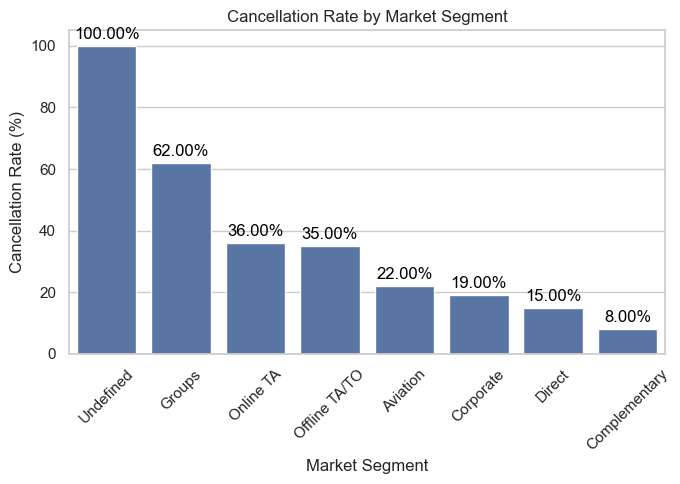

In [10]:
# cancellation rate by market segment visualization
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=cancellation_rate.index, y=cancellation_rate.values, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, color='black')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

adr_by_month = df.groupby('arrival_date_month')['adr'].mean().round(2).reindex(month_order)

In [ ]:
# Confirmation rate by month (non-cancelled / total bookings)
# Note: proxy for occupancy — true occupancy rate requires room inventory data
occupancy_by_month = df.groupby('arrival_date_month')['is_canceled'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reindex(month_order).round(2)

print(occupancy_by_month)

In [13]:
revpar_by_month = (adr_by_month * occupancy_by_month / 100).round(2)
print(revpar_by_month)

arrival_date_month
January      49.57
February     49.33
March        54.52
April        58.63
May          64.64
June         67.00
July         74.24
August       76.35
September    63.14
October      54.75
November     51.28
December     51.55
dtype: float64
